In [17]:
from swo_validation_2023_09_14 import output_dir
from misc_utils import read_jsonl_to_df, column_to as to
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
overlaps_df = read_jsonl_to_df(output_dir.glob("./*/overlaps.jsonl")).fillna({'reset_network': False, 'epochs': 100, "net": "LogProbDenseNet"})
losses_df = read_jsonl_to_df(output_dir.glob("./*/losses.jsonl")).fillna({'reset_network': False, 'epochs': 100, "net": "LogProbDenseNet"})

In [27]:
overlaps_df.groupby(['lattice', 'n_samples', 'epochs', 'n_spins', 'energy_baseline', 'net'])['iteration'].max()

lattice                                                                                                                                                                              n_samples  epochs  n_spins  energy_baseline  net                 
KagomeLattice12x12_isotropic_factor_149-150-151-152-154-155-181-182-183-184-185-186-187-188-189-190-216-217-218-219-220-221-222-223-224-225-226-251-252-253-254-255-256-257-258-291  5000       100     36       10.0             LogProbDenseNet         49
                                                                                                                                                                                                                 250.0            LogProbDenseNet         49
KagomeLattice12x12_isotropic_factor_149-151-152-182-183-184-185-186-187-188-189-190-217-218-219-220-221-222-223-224-225-252-253-254-255-256-258                                      5000       10      27       10.0             SplitGroupResConvNet 

/nix/store/nnnbq7bf556rhr0s8sgwwnr4kg1wqhn5-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


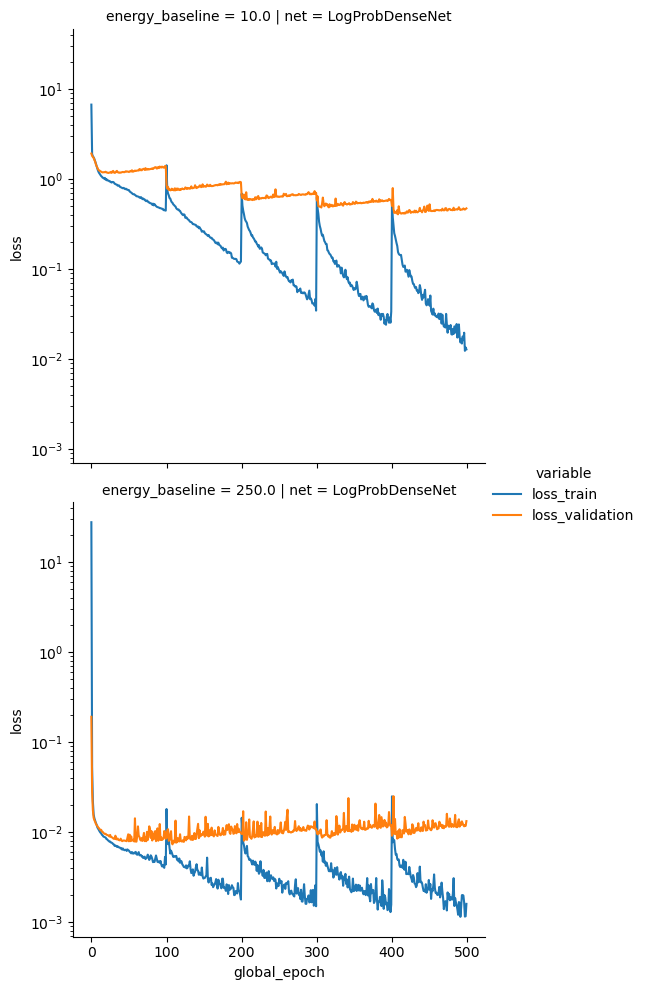

In [19]:
sns.relplot(
    losses_df.query('n_spins == 24 and iteration < 5 and epochs == 100').melt(
        id_vars=["iteration", "epoch", "global_epoch", "energy_baseline", "epochs", "reset_network", "n_spins", "net"],
        value_vars=["loss_train", "loss_validation"],
        value_name="loss",
    ),
    x="global_epoch",
    y="loss",
    hue="variable",
    kind="line",
    row="energy_baseline",
    col='net'
).set(yscale='log')

In [20]:
overlaps_df.columns

Index(['iteration', 'initial_ground_state_overlap_test',
       'new_ground_state_overlap_test', 'alpha', 'run', 'mode', 'n_samples',
       'lattice', 'energy_baseline', 'n_spins', 'epochs', 'reset_network',
       'net'],
      dtype='object')

/nix/store/nnnbq7bf556rhr0s8sgwwnr4kg1wqhn5-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


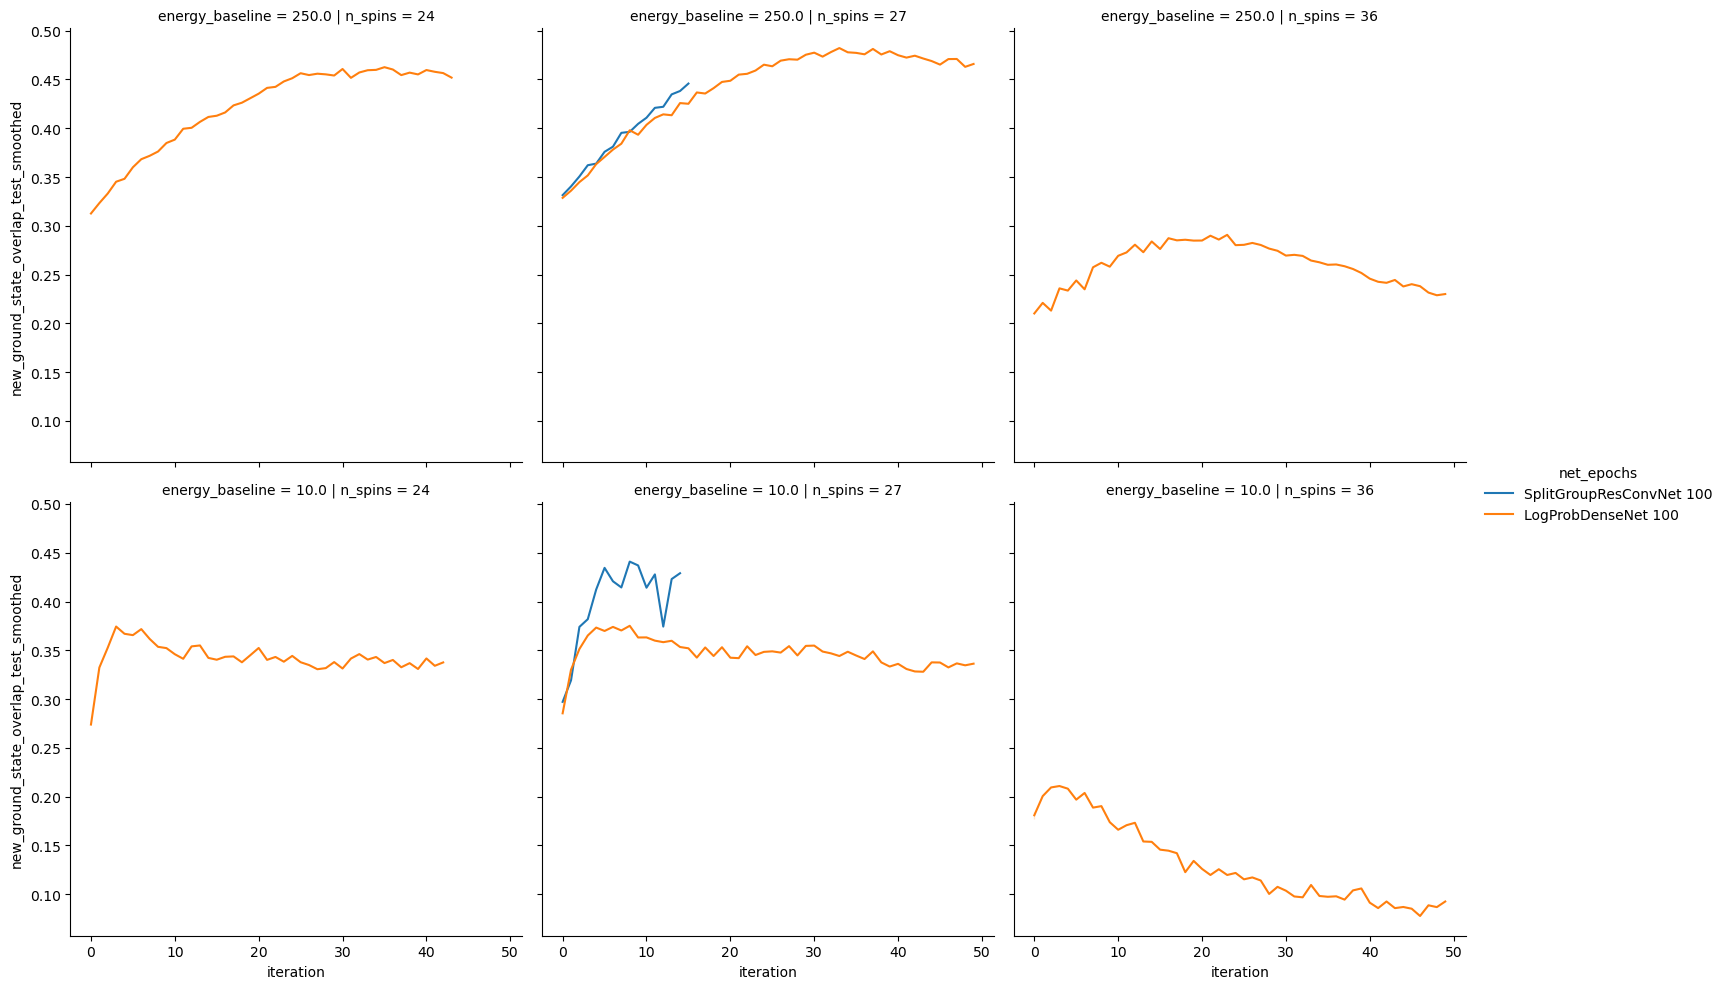

In [21]:
sns.relplot(
    data=overlaps_df.fillna({"energy_baseline": 'lanczos'}).query('n_samples == 5000 and epochs == 100')
    .assign(
        new_ground_state_overlap_test_smoothed=lambda df: df.groupby(
            ["lattice", "n_samples", "energy_baseline", "epochs", "net", "n_spins", "reset_network"]
        )["new_ground_state_overlap_test"].transform(
            lambda x: x.rolling(window=1, center=True).mean()
        ),
        net_epochs = lambda df: df["net"] + " " + df["epochs"].astype(str),
    )
    .pipe(to(str, ["energy_baseline", "n_samples", "epochs"])),
    x="iteration",
    y="new_ground_state_overlap_test_smoothed",
    # col="epochs",
    row="energy_baseline",
    hue="net_epochs",
    kind="line",
    col="n_spins",
)

In [22]:
overlaps_df

,iteration,initial_ground_state_overlap_test,new_ground_state_overlap_test,alpha,run,mode,n_samples,lattice,energy_baseline,n_spins,epochs,reset_network,net
0,0,0.330948,0.331450,None,0,power,5000,KagomeLattice12x12_isotropic_factor_149-151-15...,250.0,27,100,False,SplitGroupResConvNet
1,1,0.343134,0.340388,None,0,power,5000,KagomeLattice12x12_isotropic_factor_149-151-15...,250.0,27,100,False,SplitGroupResConvNet
2,2,0.367669,0.350582,None,0,power,5000,KagomeLattice12x12_isotropic_factor_149-151-15...,250.0,27,100,False,SplitGroupResConvNet
3,3,0.365935,0.362131,None,0,power,5000,KagomeLattice12x12_isotropic_factor_149-151-15...,250.0,27,100,False,SplitGroupResConvNet
4,4,0.408748,0.363747,None,0,power,5000,KagomeLattice12x12_isotropic_factor_149-151-15...,250.0,27,100,False,SplitGroupResConvNet
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,22,0.684405,0.449913,None,0,power,5000,KagomeLattice12x12_isotropic_factor_149-151-15...,250.0,27,10,False,SplitGroupResConvNet
370,23,0.699603,0.458165,None,0,power,5000,KagomeLattice12x12_isotropic_factor_149-151-15...,250.0,27,10,False,SplitGroupResConvNet
371,24,0.715011,0.460462,None,0,power,5000,KagomeLattice12x12_isotropic_factor_149-151-15...,250.0,27,10,False,SplitGroupResConvNet
372,25,0.709117,0.456771,None,0,power,5000,KagomeLattice12x12_isotropic_factor_149-151-15...,250.0,27,10,False,SplitGroupResConvNet


In [23]:
# (ggplot(overlaps_df.dropna(subset=['energy_baseline']), aes(x='iteration', y='new_ground_state_overlap_test', color='energy_baseline'))
#     + geom_point() + geom_smooth(method='loess')
#     + facet_grid('n_samples ~ lattice') + theme_minimal())

In [24]:
# sns.relplot(
#     overlaps_df.query("lattice == 'KagomeLattice2x3'").pipe(to_cat("energy_baseline")),
#     x="iteration",
#     y="new_ground_state_overlap_test",
#     hue="energy_baseline",
#     kind="line",
#     row="lattice",
# )
# plt.axhline(1, ls='--', color='C4')
# plt.axhline(0.9, ls='--', color='C4')


In [25]:
# sns.relplot(
#     overlaps_df.query("mode == 'power'"),
#     x="iteration",
#     y="new_ground_state_overlap_test",
#     hue="lattice",
#     kind="line",
# )
# plt.axhline(1, ls='--', color='C4')
# plt.axhline(0.9, ls='--', color='C4')
